Columns: ['Date', 'Papanasam', 'Aryankavu', 'Thenmala', 'Kalakkad', 'Thenkasi', 'Total Rainfall (mm)', 'Flood Risk']
         Date  Papanasam  Aryankavu  Thenmala  Kalakkad  Thenkasi  \
0  2024-03-01         53         15        29        41         9   
1  2024-03-02          0         18        14        64         8   
2  2024-03-03         99         19        16         7         9   
3  2024-03-04         25         23        47        17        36   
4  2024-03-05         10          6        18         6        92   

   Total Rainfall (mm) Flood Risk  
0                  147        Yes  
1                  104        Yes  
2                  150        Yes  
3                  148        Yes  
4                  132        Yes  

📊 Model Comparison Table:
| Model               |   Accuracy (%) |   Recall (%) |   ROC AUC (%) |
|---------------------|----------------|--------------|---------------|
| Random Forest       |         100    |       100    |           100 |
| SVM    

C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


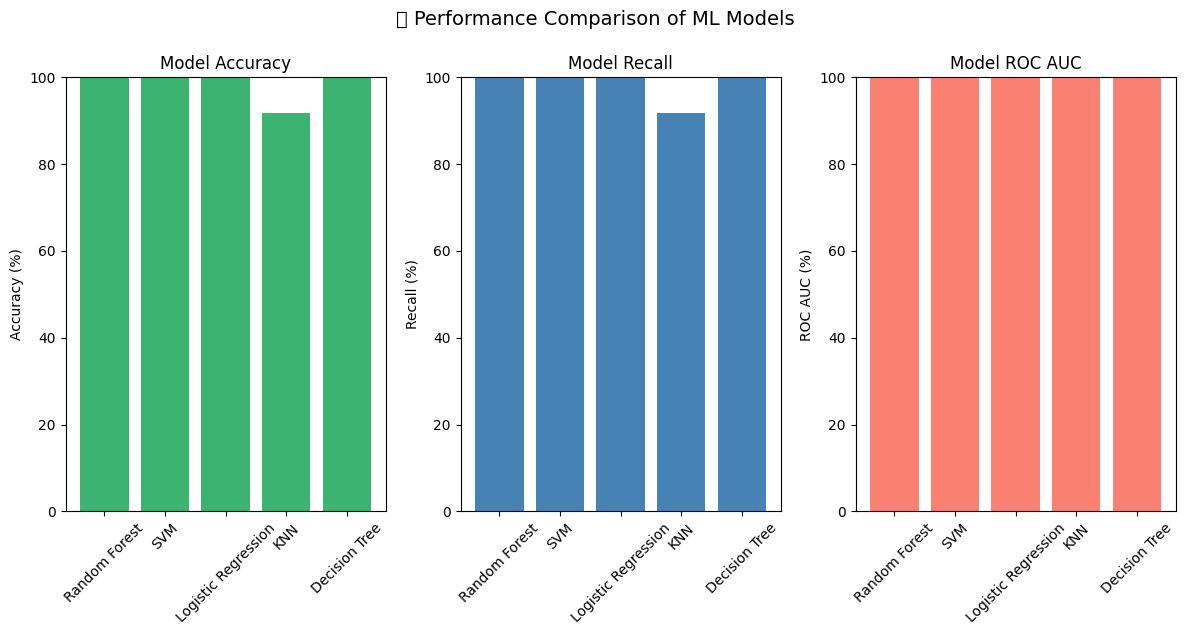

In [2]:
# ----------------- Imports -----------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from tabulate import tabulate
import matplotlib.pyplot as plt

# ----------------- Load Dataset -----------------
df = pd.read_csv("waterfall_data.csv")  # Replace with actual path if needed
print("Columns:", df.columns.tolist())
print(df.head())

# ----------------- Preprocess -----------------
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

df.dropna(inplace=True)

X = df.drop(columns=df.columns[-1])  # All except last column
y = df[df.columns[-1]]               # Last column is target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------- Models -----------------
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

# ----------------- Evaluation -----------------
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        roc = roc_auc_score(y_test, y_prob, multi_class='ovo', average='macro')
    else:
        roc = 0.0

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='macro')

    results.append({
        "Model": name,
        "Accuracy (%)": round(accuracy * 100, 2),
        "Recall (%)": round(recall * 100, 2),
        "ROC AUC (%)": round(roc * 100, 2)
    })

# ----------------- Output Table -----------------
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values(by=["Accuracy (%)", "Recall (%)", "ROC AUC (%)"], ascending=False)

print("\n📊 Model Comparison Table:")
print(tabulate(df_results_sorted, headers="keys", tablefmt="github", showindex=False))

# ----------------- Graphical Representation -----------------
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 3, 1)
plt.bar(df_results["Model"], df_results["Accuracy (%)"], color='mediumseagreen')
plt.title("Model Accuracy")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)

# Plot Recall
plt.subplot(1, 3, 2)
plt.bar(df_results["Model"], df_results["Recall (%)"], color='steelblue')
plt.title("Model Recall")
plt.ylabel("Recall (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)

# Plot ROC AUC
plt.subplot(1, 3, 3)
plt.bar(df_results["Model"], df_results["ROC AUC (%)"], color='salmon')
plt.title("Model ROC AUC")
plt.ylabel("ROC AUC (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.suptitle("📈 Performance Comparison of ML Models", fontsize=14, y=1.05)
plt.show()
